# 方差过滤

In [20]:
#1.导入所需要的库
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
import numpy as np
from sklearn.preprocessing import StandardScaler

In [21]:
# 2.导入数据集，探索数据
data = pd.read_csv(r"E:\高密度脑电前额项目\code\EEG\feature_analysis\HD\new5\guozhiwei\random\clean\guo.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Columns: 385 entries, mean_0 to Label
dtypes: float64(385)
memory usage: 1.4 MB


In [22]:
data.shape

(474, 385)

In [23]:
data.head()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
0,0.564504,0.346097,-0.153000,1.476961,0.428192,-0.040000,1.238615,-0.012700,0.055712,0.278742,...,2.524660,4.684655,3.029470,2.463650,2.460537,2.644575,2.484005,2.654804,2.677142,0.0
1,0.231096,0.127935,0.227890,-1.120000,-0.021100,-0.031200,-1.720000,-0.006280,0.072716,-2.310000,...,2.754616,4.998364,3.796504,2.780415,2.786529,2.988513,2.644508,2.885961,2.914553,1.0
2,-0.077200,-0.696000,0.335459,0.902309,-0.848000,0.262331,1.179692,0.320767,0.301330,1.132247,...,2.908851,5.006298,3.781389,2.909252,3.055818,3.128134,2.767541,3.038339,3.134944,1.0
3,-0.622000,-0.467000,3.132454,0.481109,-0.458000,3.125935,-1.130000,3.275701,3.181828,-0.867000,...,3.191039,5.059892,3.808327,3.298709,3.264276,3.399790,3.388690,3.388930,3.420387,0.0
4,-0.364000,-0.641000,0.661753,0.436050,-0.672000,0.807928,1.316952,0.718367,0.761854,2.103246,...,2.936247,4.594639,3.657660,2.970049,2.975326,3.087854,2.880605,2.981892,3.017463,2.0


In [24]:
data.describe()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,...,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,-0.001169,0.000849,-0.007558,0.001767,0.001950,-0.006099,0.001153,-0.006652,-0.006578,0.004757,...,2.849874,4.832112,3.655274,2.853339,2.862046,3.010183,2.894312,3.002602,3.024280,1.000000
std,5.649986,11.271259,3.471707,4.406974,11.448889,6.253604,5.863323,3.526968,4.060394,5.944873,...,0.601199,0.563599,0.705127,0.600563,0.601620,0.586882,0.783757,0.715113,0.674552,0.817359
min,-66.400000,-141.000000,-32.500000,-40.300000,-144.000000,-50.900000,-65.400000,-29.400000,-39.100000,-70.200000,...,1.705455,3.225825,2.159811,1.779526,1.675307,1.669998,1.667966,1.720235,1.598793,0.000000
25%,-0.437500,-0.483500,-0.464500,-0.741500,-0.514000,-0.496250,-0.983000,-0.487750,-0.501500,-0.836000,...,2.495111,4.595185,3.299942,2.484099,2.492211,2.657419,2.454444,2.590100,2.642172,0.000000
50%,0.008941,0.014321,-0.047900,0.016159,-0.011445,-0.037100,0.043959,-0.020900,-0.041750,0.042431,...,2.750029,4.876390,3.594358,2.761093,2.768079,2.950922,2.732451,2.885555,2.941152,1.000000
75%,0.445678,0.504904,0.432265,0.817643,0.484522,0.435601,0.922226,0.456790,0.449388,0.841110,...,3.062313,5.128806,3.892410,3.056874,3.069659,3.231939,3.074779,3.190787,3.211766,2.000000
max,65.835827,143.553768,31.914733,41.460271,147.167005,50.137826,64.104786,28.704655,38.256417,68.718688,...,6.541936,6.945132,7.317867,6.540212,6.508479,6.466820,7.059287,6.801109,6.732697,2.000000


In [25]:
from sklearn.preprocessing import LabelEncoder
y = data.iloc[:,-1]#要输入的是标签，不是特征矩阵，所以允许一维

In [26]:
le = LabelEncoder()  # 实例化
le = le.fit(y) # 导入数据
label = le.transform(y) # transform接口调取数据
le.classes_  #属性.classes_查看标签中究竟有多少类别
label

array([0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0,
       1, 2, 2, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 2, 0, 1, 1,
       0, 2, 1, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 1, 0, 1,
       2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 1, 0, 0, 1, 2,
       1, 0, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 2, 0, 1, 1, 1, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 0,
       1, 0, 1, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2, 2,
       1, 2, 2, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 1, 1, 0, 2, 1, 1, 0,
       2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1,
       1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 1, 2, 2,
       1, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2,
       1, 1, 0, 1, 1, 2, 0, 2, 1, 1, 2, 0, 2, 0, 2,

In [27]:
le.fit_transform(y)  #也可以直接fit_transform一步到位

array([0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0,
       1, 2, 2, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 2, 0, 1, 1,
       0, 2, 1, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 2, 0, 1, 0, 1,
       2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 2, 1, 2, 1, 1, 0, 0, 1, 2,
       1, 0, 0, 0, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 2, 0, 1, 1, 1, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 0,
       1, 0, 1, 2, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2, 2,
       1, 2, 2, 1, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 1, 1, 0, 2, 1, 1, 0,
       2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 1, 0, 2, 0, 2, 2, 1, 2, 1, 2, 1,
       1, 1, 1, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 1, 2, 2,
       1, 2, 2, 2, 0, 0, 2, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2,
       1, 1, 0, 1, 1, 2, 0, 2, 1, 1, 2, 0, 2, 0, 2,

In [28]:
le.inverse_transform(label)  #使用inverse_transform可以逆转

array([0., 1., 1., 0., 2., 1., 1., 1., 1., 1., 1., 2., 1., 0., 1., 0., 0.,
       2., 2., 0., 1., 0., 2., 2., 1., 0., 2., 2., 0., 1., 2., 2., 0., 0.,
       2., 1., 1., 0., 2., 2., 0., 0., 0., 0., 1., 2., 2., 0., 1., 0., 1.,
       0., 2., 2., 1., 0., 0., 2., 2., 2., 1., 2., 2., 0., 1., 1., 0., 2.,
       1., 0., 0., 0., 0., 1., 0., 2., 1., 1., 1., 0., 2., 1., 1., 1., 0.,
       1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 2., 0., 1., 0., 1., 2., 2., 1., 0., 1., 1., 1., 0., 1.,
       1., 0., 1., 0., 2., 1., 2., 1., 1., 0., 0., 1., 2., 1., 0., 0., 0.,
       1., 2., 0., 2., 1., 2., 0., 2., 0., 1., 0., 2., 0., 1., 1., 1., 2.,
       2., 2., 2., 0., 0., 0., 0., 0., 2., 0., 1., 2., 0., 0., 1., 0., 0.,
       1., 0., 2., 0., 0., 0., 1., 0., 1., 2., 0., 0., 2., 0., 0., 0., 1.,
       1., 2., 2., 1., 0., 1., 1., 1., 0., 2., 2., 1., 2., 2., 1., 2., 0.,
       2., 2., 0., 0., 2., 0., 2., 2., 2., 1., 1., 0., 2., 1., 1., 0., 2.,
       2., 2., 2., 2., 1.

In [29]:
data.iloc[:,-1] = label  #让标签等于我们运行出来的结果
data.head()


,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47,Label
0,0.564504,0.346097,-0.153000,1.476961,0.428192,-0.040000,1.238615,-0.012700,0.055712,0.278742,...,2.524660,4.684655,3.029470,2.463650,2.460537,2.644575,2.484005,2.654804,2.677142,0.0
1,0.231096,0.127935,0.227890,-1.120000,-0.021100,-0.031200,-1.720000,-0.006280,0.072716,-2.310000,...,2.754616,4.998364,3.796504,2.780415,2.786529,2.988513,2.644508,2.885961,2.914553,1.0
2,-0.077200,-0.696000,0.335459,0.902309,-0.848000,0.262331,1.179692,0.320767,0.301330,1.132247,...,2.908851,5.006298,3.781389,2.909252,3.055818,3.128134,2.767541,3.038339,3.134944,1.0
3,-0.622000,-0.467000,3.132454,0.481109,-0.458000,3.125935,-1.130000,3.275701,3.181828,-0.867000,...,3.191039,5.059892,3.808327,3.298709,3.264276,3.399790,3.388690,3.388930,3.420387,0.0
4,-0.364000,-0.641000,0.661753,0.436050,-0.672000,0.807928,1.316952,0.718367,0.761854,2.103246,...,2.936247,4.594639,3.657660,2.970049,2.975326,3.087854,2.880605,2.981892,3.017463,2.0


In [30]:
print(data.columns)

Index(['mean_0', 'mean_1', 'mean_2', 'mean_3', 'mean_4', 'mean_5', 'mean_6',
       'mean_7', 'mean_8', 'mean_9',
       ...
       'DE_39', 'DE_40', 'DE_41', 'DE_42', 'DE_43', 'DE_44', 'DE_45', 'DE_46',
       'DE_47', 'Label'],
      dtype='object', length=385)


In [31]:
data['Label']

0      0.0
1      1.0
2      1.0
3      0.0
4      2.0
      ... 
469    0.0
470    2.0
471    2.0
472    2.0
473    0.0
Name: Label, Length: 474, dtype: float64

In [32]:
data.shape

(474, 385)

In [33]:
x = data.iloc[:,0:384]
x.head()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_38,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47
0,0.564504,0.346097,-0.153000,1.476961,0.428192,-0.040000,1.238615,-0.012700,0.055712,0.278742,...,3.574020,2.524660,4.684655,3.029470,2.463650,2.460537,2.644575,2.484005,2.654804,2.677142
1,0.231096,0.127935,0.227890,-1.120000,-0.021100,-0.031200,-1.720000,-0.006280,0.072716,-2.310000,...,4.391907,2.754616,4.998364,3.796504,2.780415,2.786529,2.988513,2.644508,2.885961,2.914553
2,-0.077200,-0.696000,0.335459,0.902309,-0.848000,0.262331,1.179692,0.320767,0.301330,1.132247,...,4.232184,2.908851,5.006298,3.781389,2.909252,3.055818,3.128134,2.767541,3.038339,3.134944
3,-0.622000,-0.467000,3.132454,0.481109,-0.458000,3.125935,-1.130000,3.275701,3.181828,-0.867000,...,4.491755,3.191039,5.059892,3.808327,3.298709,3.264276,3.399790,3.388690,3.388930,3.420387
4,-0.364000,-0.641000,0.661753,0.436050,-0.672000,0.807928,1.316952,0.718367,0.761854,2.103246,...,4.090307,2.936247,4.594639,3.657660,2.970049,2.975326,3.087854,2.880605,2.981892,3.017463


In [34]:
x.describe()

,mean_0,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,...,DE_38,DE_39,DE_40,DE_41,DE_42,DE_43,DE_44,DE_45,DE_46,DE_47
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,...,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,-0.001169,0.000849,-0.007558,0.001767,0.001950,-0.006099,0.001153,-0.006652,-0.006578,0.004757,...,4.018633,2.849874,4.832112,3.655274,2.853339,2.862046,3.010183,2.894312,3.002602,3.024280
std,5.649986,11.271259,3.471707,4.406974,11.448889,6.253604,5.863323,3.526968,4.060394,5.944873,...,0.499256,0.601199,0.563599,0.705127,0.600563,0.601620,0.586882,0.783757,0.715113,0.674552
min,-66.400000,-141.000000,-32.500000,-40.300000,-144.000000,-50.900000,-65.400000,-29.400000,-39.100000,-70.200000,...,2.612828,1.705455,3.225825,2.159811,1.779526,1.675307,1.669998,1.667966,1.720235,1.598793
25%,-0.437500,-0.483500,-0.464500,-0.741500,-0.514000,-0.496250,-0.983000,-0.487750,-0.501500,-0.836000,...,3.739918,2.495111,4.595185,3.299942,2.484099,2.492211,2.657419,2.454444,2.590100,2.642172
50%,0.008941,0.014321,-0.047900,0.016159,-0.011445,-0.037100,0.043959,-0.020900,-0.041750,0.042431,...,4.043229,2.750029,4.876390,3.594358,2.761093,2.768079,2.950922,2.732451,2.885555,2.941152
75%,0.445678,0.504904,0.432265,0.817643,0.484522,0.435601,0.922226,0.456790,0.449388,0.841110,...,4.334799,3.062313,5.128806,3.892410,3.056874,3.069659,3.231939,3.074779,3.190787,3.211766
max,65.835827,143.553768,31.914733,41.460271,147.167005,50.137826,64.104786,28.704655,38.256417,68.718688,...,6.071563,6.541936,6.945132,7.317867,6.540212,6.508479,6.466820,7.059287,6.801109,6.732697


In [35]:
Xtrain,Xtest,Ytrain,Ytest = train_test_split(x,y,test_size=0.1,random_state=10)
print(Xtrain.shape,Xtest.shape,Ytrain.shape,Ytest.shape)

(426, 384) (48, 384) (426,) (48,)


SVC
****Results****
Accuracy: 35.4167%
Log Loss: 1.1069256175445563
NuSVC
****Results****
Accuracy: 41.6667%
Log Loss: 1.0790026331838118
RandomForestClassifier
****Results****
Accuracy: 52.0833%
Log Loss: 1.0581464902344686
GaussianNB
****Results****
Accuracy: 27.0833%
Log Loss: 18.810596750700736
LinearDiscriminantAnalysis
****Results****
Accuracy: 31.2500%
Log Loss: 12.165416564974755
QuadraticDiscriminantAnalysis
****Results****
Accuracy: 37.5000%
Log Loss: 22.527283368198223


D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\metrics\_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


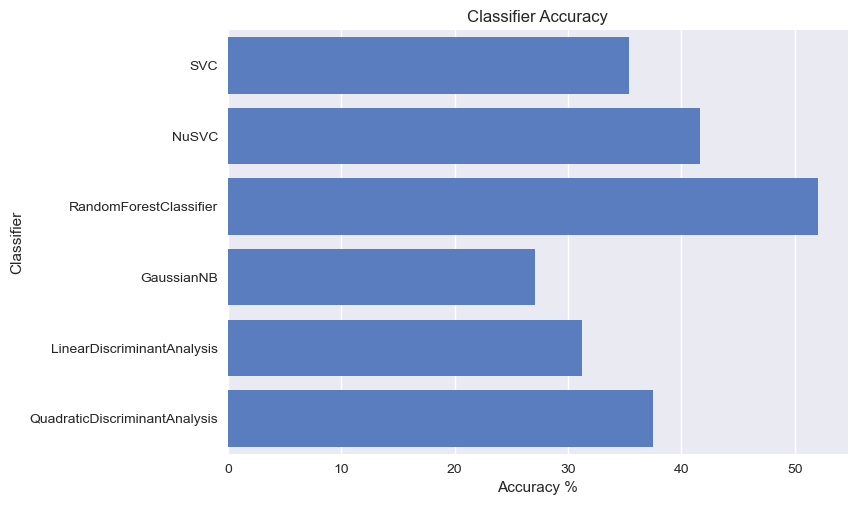

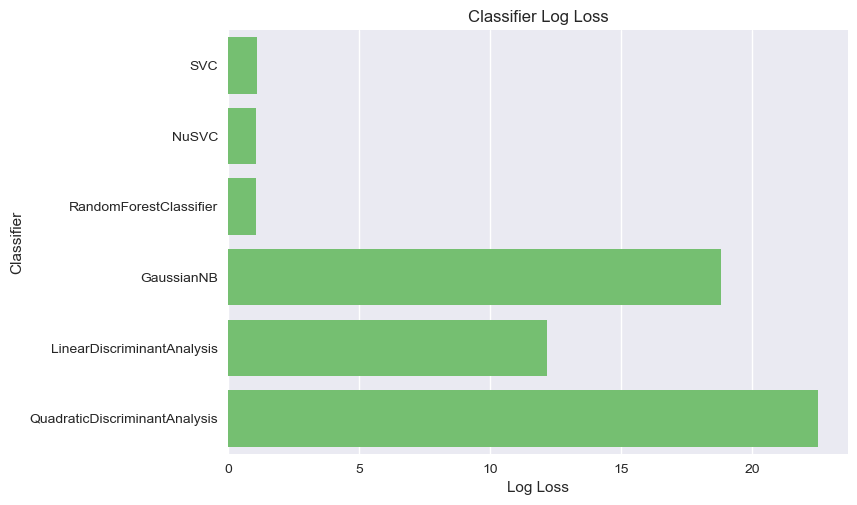

In [36]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.neighbors import KNeighborsClassifier  # k近邻算法
from sklearn.svm import SVC, LinearSVC, NuSVC   #支持向量机分类器、线性支持向量机分类器、核支持向量分类
from sklearn.tree import DecisionTreeClassifier   # 决策树
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier   # 随机森林、AdaBoost、GradientBoost
from sklearn.naive_bayes import GaussianNB    #朴素贝叶斯GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis   #线性判别分析
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis   #二次判别分析
import pandas as pd 
import seaborn as sns

classifiers = [
#    KNeighborsClassifier(2),
    SVC(kernel="rbf",probability=True),
    NuSVC(probability=True),
#    DecisionTreeClassifier(),
    RandomForestClassifier(),
#    AdaBoostClassifier(),
#    GradientBoostingClassifier(),
     GaussianNB(),
    LinearDiscriminantAnalysis(solver='svd'),
    QuadraticDiscriminantAnalysis()]

# 结果可视化
log_cols=["Classifier", "Accuracy", "Log Loss"]
log = pd.DataFrame(columns=log_cols)

for clf in classifiers:
    clf.fit(Xtrain, Ytrain)
    name = clf.__class__.__name__

    print("="*30)
    print(name)

    print('****Results****')
    train_predictions = clf.predict(Xtest)
    acc = accuracy_score(Ytest, train_predictions)
    print("Accuracy: {:.4%}".format(acc))

    train_predictions = clf.predict_proba(Xtest)
    ll = log_loss(Ytest, train_predictions)
    print("Log Loss: {}".format(ll))

    log_entry = pd.DataFrame([[name, acc*100, ll]], columns=log_cols)
    log = log._append(log_entry)

print("="*30)
sns.set_color_codes("muted")
sns.barplot(x='Accuracy', y='Classifier', data=log, color="b")

plt.xlabel('Accuracy %')
plt.title('Classifier Accuracy')
plt.show()

sns.set_color_codes("muted")
sns.barplot(x='Log Loss', y='Classifier', data=log, color="g")

plt.xlabel('Log Loss')
plt.title('Classifier Log Loss')
plt.show()

D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


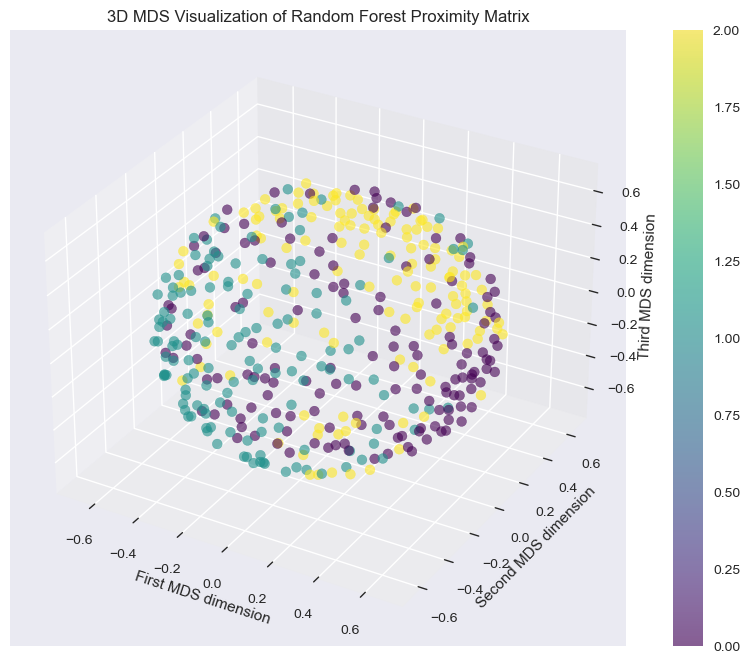

In [37]:
import numpy as np  
import pandas as pd  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.manifold import MDS  
import matplotlib.pyplot as plt  

# 1. 训练随机森林  
rf = RandomForestClassifier(n_estimators=100)  
rf.fit(Xtrain, Ytrain) 

# 2. 计算样本间的相似度矩阵  
def proximity_matrix(rf, Xtrain):  
    terminals = rf.apply(Xtrain)  
    n_samples = Xtrain.shape[0]  
    proximity = np.zeros((n_samples, n_samples))  
    
    for tree in range(terminals.shape[1]):  
        for i in range(n_samples):  
            for j in range(i, n_samples):  
                if terminals[i, tree] == terminals[j, tree]:  
                    proximity[i, j] += 1  
                    proximity[j, i] += 1  
    
    return proximity / terminals.shape[1]  

prox_matrix = proximity_matrix(rf, Xtrain)  
dissimilarity = 1 - prox_matrix  

# 3. 使用MDS进行降维  
mds = MDS(n_components=3, dissimilarity='precomputed')  
X_mds_3d = mds.fit_transform(dissimilarity)  

# 4. 绘图  
fig = plt.figure(figsize=(12, 8))  
ax = fig.add_subplot(111, projection='3d')  

# 绘制散点图  
scatter = ax.scatter(X_mds_3d[:, 0],   
                    X_mds_3d[:, 1],   
                    X_mds_3d[:, 2],  
                    c=Ytrain,  
                    cmap='viridis',  
                    s=50,  
                    alpha=0.6)  

# 添加颜色条  
plt.colorbar(scatter)  

# 设置标签  
ax.set_xlabel('First MDS dimension')  
ax.set_ylabel('Second MDS dimension')  
ax.set_zlabel('Third MDS dimension')  
ax.set_title('3D MDS Visualization of Random Forest Proximity Matrix')  

# 添加交互性：可以旋转查看  
plt.show() 


C:\Users\PC233\AppData\Local\Temp\ipykernel_19224\4181796013.py:9: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


Training Random Forest...
Calculating proximity matrix...
Performing MDS...


D:\anaconda\envs\HDEEG\lib\site-packages\sklearn\manifold\_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


Creating visualization...


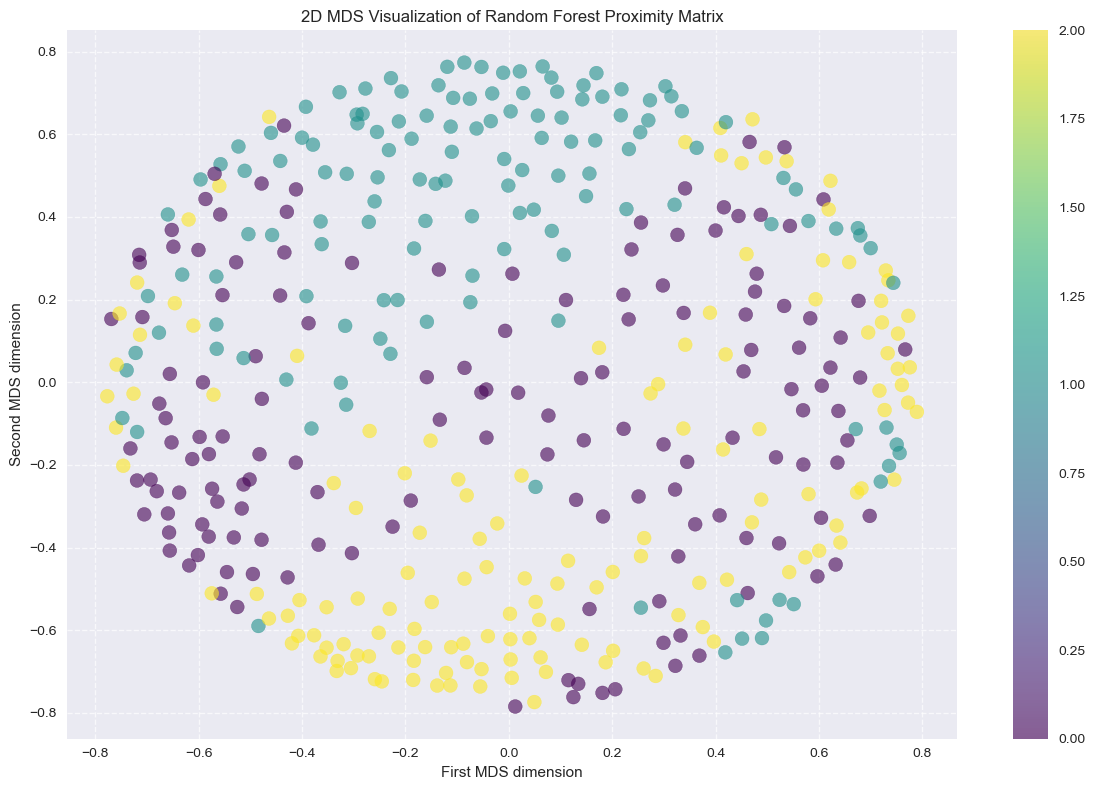

Number of samples: 426
Number of features: 384
Number of classes: 3
MDS stress value: 14074.1776


In [38]:
import numpy as np  
import pandas as pd  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.manifold import MDS  
import matplotlib.pyplot as plt  
import seaborn as sns  

# 设置绘图风格  
plt.style.use('seaborn')  
sns.set_palette('husl')  

# 1. 训练随机森林  
print("Training Random Forest...")  
rf = RandomForestClassifier(n_estimators=100, random_state=42)  
rf.fit(Xtrain, Ytrain)  

# 2. 计算样本间的相似度矩阵  
def proximity_matrix(rf, Xtrain):  
    print("Calculating proximity matrix...")  
    terminals = rf.apply(Xtrain)  
    n_samples = Xtrain.shape[0]  
    proximity = np.zeros((n_samples, n_samples))  
    
    for tree in range(terminals.shape[1]):  
        for i in range(n_samples):  
            for j in range(i, n_samples):  
                if terminals[i, tree] == terminals[j, tree]:  
                    proximity[i, j] += 1  
                    proximity[j, i] += 1  
    
    return proximity / terminals.shape[1]  

# 计算相似度矩阵  
prox_matrix = proximity_matrix(rf, Xtrain)  
dissimilarity = 1 - prox_matrix  

# 3. 使用MDS进行降维（改为2维）  
print("Performing MDS...")  
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)  
X_mds_2d = mds.fit_transform(dissimilarity)  

# 4. 绘图  
print("Creating visualization...")  
plt.figure(figsize=(12, 8))  

# 创建散点图  
scatter = plt.scatter(X_mds_2d[:, 0],   
                     X_mds_2d[:, 1],  
                     c=Ytrain,  
                     cmap='viridis',  
                     s=100,  # 点的大小  
                     alpha=0.6)  # 透明度  

# 添加颜色条  
plt.colorbar(scatter)  

# 设置标签和标题  
plt.xlabel('First MDS dimension')  
plt.ylabel('Second MDS dimension')  
plt.title('2D MDS Visualization of Random Forest Proximity Matrix')  

# 添加网格  
plt.grid(True, linestyle='--', alpha=0.7)  

# 优化布局  
plt.tight_layout()  

# 显示图形  
plt.show()  

# 输出一些基本统计信息  
print(f"Number of samples: {len(Xtrain)}")  
print(f"Number of features: {Xtrain.shape[1]}")  
print(f"Number of classes: {len(np.unique(Ytrain))}")  

# 计算和打印应力值（stress value）  
stress = mds.stress_  
print(f"MDS stress value: {stress:.4f}")  

In [39]:
import os
from numpy import loadtxt
import xgboost as xgb
from numpy import sort
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn import datasets
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectFromModel
import warnings
from matplotlib import  pyplot
import matplotlib.pyplot as plt
import matplotlib.pyplot as plot
warnings.filterwarnings("ignore")
# 加载数据集

CV accuracy scores:[0.37209302 0.48837209 0.37209302 0.3255814  0.46511628 0.46511628
 0.5952381  0.45238095 0.35714286 0.38095238]
Accuracy for XGBoost Classifier :  0.42740863787375416
[1.89697754e-03 1.64755760e-03 1.95669895e-03 2.52830843e-03
 1.23656343e-03 2.12825346e-03 1.41688786e-03 2.42190412e-03
 1.72856497e-03 1.46231148e-03 2.20322493e-03 2.75394600e-03
 1.75339170e-03 1.81053602e-03 1.27548911e-03 6.98382175e-03
 3.16542992e-03 2.38844240e-03 1.17180473e-03 1.54218636e-03
 2.76300823e-03 1.80956710e-03 2.53311358e-03 1.41189306e-03
 2.87341792e-03 1.92021544e-03 2.27855542e-03 2.56898347e-03
 2.96360045e-03 4.24871175e-03 1.49541174e-03 1.58661325e-03
 1.39901484e-03 2.57243030e-03 2.19113752e-03 1.50024891e-03
 1.68752752e-03 2.39373744e-03 2.00159778e-03 3.59697430e-03
 5.56846848e-04 3.19414004e-03 7.50187319e-04 1.08186028e-03
 7.64507195e-03 9.89726977e-04 2.13182112e-03 1.45328604e-03
 1.35109294e-03 2.31642765e-03 4.04727180e-03 2.22648866e-03
 1.77815917e-03 2.82

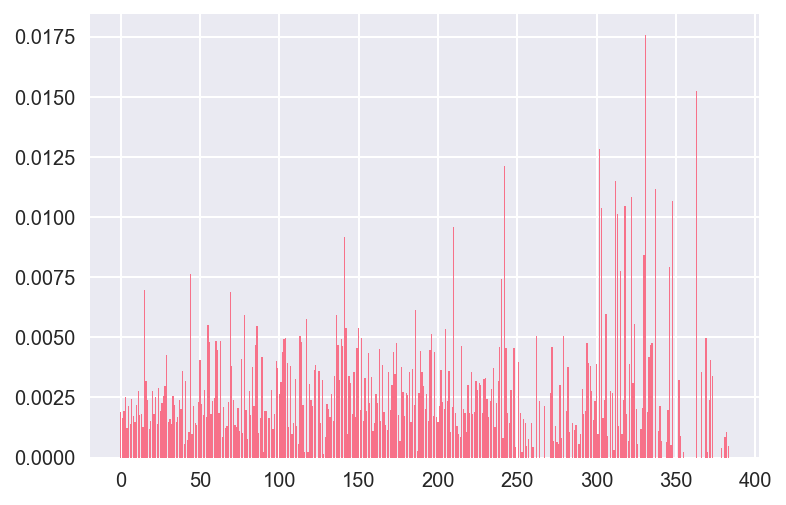

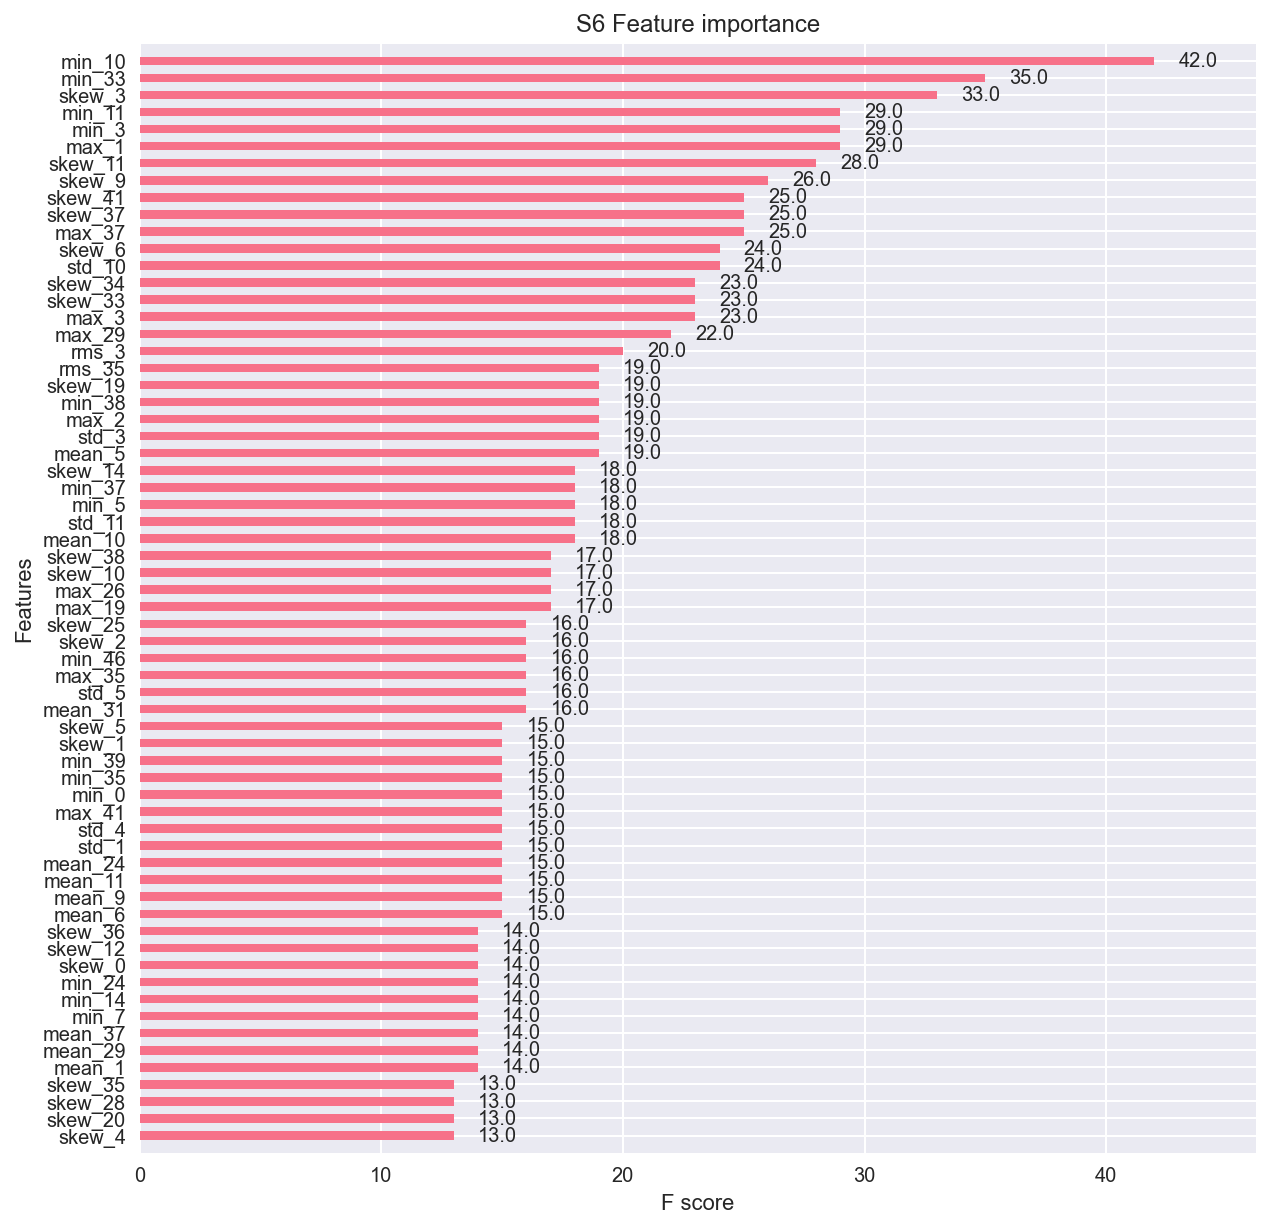

Accuracy: 39.58%
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.89445870e-06 1.42716497e-04 2.15116306e-04 2.17139415e-04
 2.24810734e-04 2.33481071e-04 2.33989951e-04 2.34057399e-04
 2.65886163e-04 3.18537699e-04 3.80526209e-04 4.30403015e-04
 4.37927782e-04 4.65646473e-04 4.68397775e-04 5.44365961e-04
 5.49246441e-04 5.52632962e-04 5.56846848e-04 5.67750831e-04
 5.70827047e-04 6.52787858e-04 6.63321058e-04 6.80569152e-04
 6.8247

In [40]:
          #数据预处理---scale标准化

model=XGBClassifier(objective='multi:softmax',
                                                       n_estimators=150,  # 迭代次数
                                                       learning_rate=0.2,  # 步长
                                                       max_depth=3,  # 树的最大深度
                                                       min_child_weight=1,  # 决定最小叶子节点样本权重和
                                                    
                                                      subsample=0.8,  # 每个决策树所用的子样本占总样本的比例（作用于样本）
                                                       colsample_bytree=0.8, 

                                                     )

#model = XGBClassifier()
model.fit(Xtrain, Ytrain)




scores = cross_val_score(model, Xtrain, Ytrain, cv=10)
print("CV accuracy scores:%s" % scores)
print('Accuracy for XGBoost Classifier : ', scores.mean())
# 变量重要性列表
print(model.feature_importances_)

# 变量重要性可视化

plt.figure(figsize=(6,4), dpi=144)
pyplot.bar(range(len(model.feature_importances_)), model.feature_importances_)


# 变量重要性排序可视化

 
fig,ax = plt.subplots(figsize=(10,10), dpi=144)
plot_importance(model,
                height=0.5,
                ax=ax,
                 title='S6 Feature importance',
                max_num_features=64,
             )
#plt.savefig('./output/img_S6bar32.svg')
plt.show()


# make predictions for test data and evaluate
y_pred = model.predict(Xtest)
predictions = [round(value) for value in y_pred]
accuracy = accuracy_score(Ytest, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


#plot_importance(pl_xgb)
thresholds = sort(model.feature_importances_)
print(thresholds)



acc = []
for thresh in thresholds: # 遍历所有的特征重要性得分，把每个得分作为阈值进行特征选择
    # select features using threshold
    selection = SelectFromModel(model, threshold=thresh, prefit=True)
    select_Xtrain = selection.transform(Xtrain)
# train model
    selection_model = XGBClassifier()
    selection_model.fit(select_Xtrain, Ytrain)
# eval model
    select_Xtest = selection.transform(Xtest)
    y_pred = selection_model.predict(select_Xtest)
    predictions = [round(value) for value in y_pred]
    accuracy = accuracy_score(Ytest, predictions)
    
   
    acc.append(accuracy)
    print("Thresh=%.3f, n=%d, Accuracy: %.2f%%" % (thresh, select_Xtrain.shape[1], accuracy*100.0))

print(acc)
    

In [41]:
print(type(Xtrain))

<class 'pandas.core.frame.DataFrame'>


In [103]:
# 检查数据类型并打印原始信息  
print("原始数据信息:")  
print("Xtrain类型:", type(Xtrain))  
print("Xtrain形状:", Xtrain.shape)  

# 将DataFrame转换为numpy数组  
Xtrain = Xtrain.values  
print("\n转换后:")  
print("Xtrain类型:", type(Xtrain))  
print("Xtrain形状:", Xtrain.shape)  

# 确保数据类型是浮点型  
Xtrain = Xtrain.astype(np.float32)  

# 检查数据是否正确转换  
print("\n数据检查:")  
print("数据类型:", Xtrain.dtype)  
print("是否有缺失值:", np.any(np.isnan(Xtrain)))  
print("是否有无穷值:", np.any(np.isinf(Xtrain)))

原始数据信息:
Xtrain类型: <class 'pandas.core.frame.DataFrame'>
Xtrain形状: (453, 288)

转换后:
Xtrain类型: <class 'numpy.ndarray'>
Xtrain形状: (453, 288)

数据检查:
数据类型: float32
是否有缺失值: False
是否有无穷值: False


In [104]:
from sklearn.manifold import TSNE
import time
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
%matplotlib inline

import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('muted')
sns.set_context("notebook", font_scale=1.5,
                rc={"lines.linewidth": 2.5})
RS = 123


time_start = time.time()

fashion_tsne = TSNE(random_state=RS, n_jobs=-1).fit_transform(Xtrain)

print(f't-SNE done! Time elapsed: {time.time()-time_start} seconds')



AttributeError: 'NoneType' object has no attribute 'split'

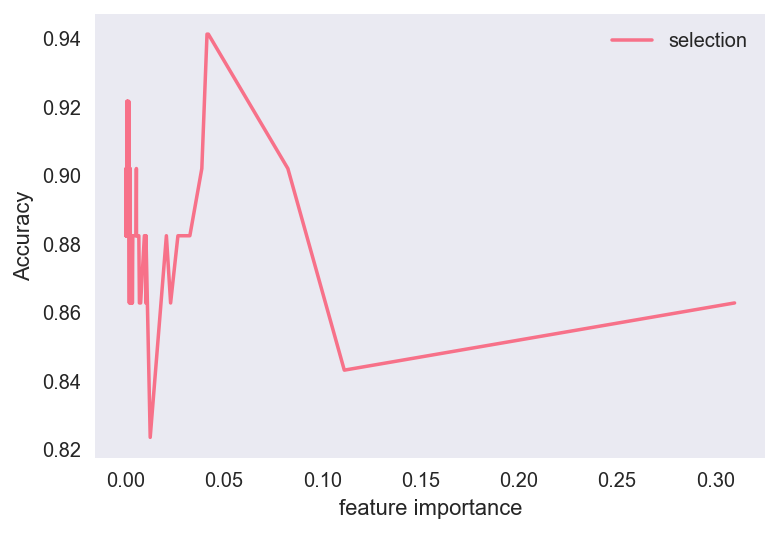

In [74]:
import matplotlib.pyplot as plt



plt.show()
plt.figure(figsize=(6,4), dpi=144)
plt.grid()
plt.xlabel("feature importance")
plt.ylabel("Accuracy")
plt.plot( thresholds,acc, label='selection')
#plt.savefig('./output/img_S6cur32.svg')
plt.legend()

In [35]:
print(Ytest)
a=np.count_nonzero(Ytest == 1)#Neg
b=np.count_nonzero(Ytest == 2)#Pos
c=np.count_nonzero(Ytest == 0)#Neu
print(a)
print(b)
print(c)

238    1.0
307    2.0
175    0.0
163    1.0
242    2.0
452    0.0
223    0.0
98     2.0
228    1.0
230    2.0
301    0.0
403    2.0
192    1.0
142    0.0
276    1.0
88     2.0
324    0.0
108    0.0
174    2.0
152    1.0
472    2.0
432    1.0
415    2.0
327    0.0
190    2.0
129    1.0
7      0.0
194    2.0
281    2.0
315    2.0
343    0.0
102    2.0
370    1.0
43     2.0
211    1.0
346    1.0
114    1.0
274    0.0
304    0.0
330    1.0
502    2.0
478    0.0
164    0.0
222    1.0
47     1.0
226    2.0
474    2.0
489    0.0
279    1.0
24     2.0
176    2.0
Name: Label, dtype: float64
16
20
15


In [36]:
#多分类：混淆矩阵

from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(Ytest,y_pred)
cfm_normalized = cfm.astype('float') / cfm.sum(axis=1)[:, np.newaxis]
print(cfm_normalized)
print(cfm)

[[1.     0.     0.    ]
 [0.     0.8125 0.1875]
 [0.     0.2    0.8   ]]
[[15  0  0]
 [ 0 13  3]
 [ 0  4 16]]


<Axes: >

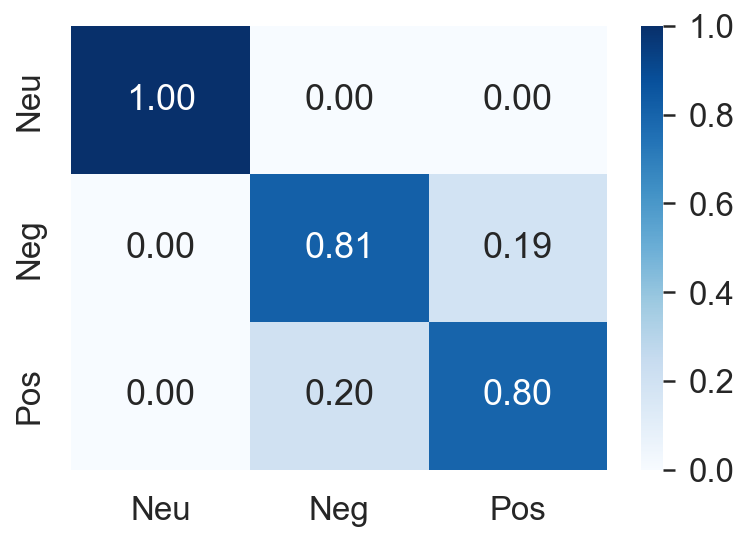

In [37]:
import seaborn as sns

labels=["Neu","Neg","Pos"]
plt.figure(figsize=(6,4), dpi=144)
plt.xlabel("S6")
sns.heatmap(cfm_normalized,annot=True,cmap='Blues',xticklabels=labels,yticklabels= labels,fmt='.2f')



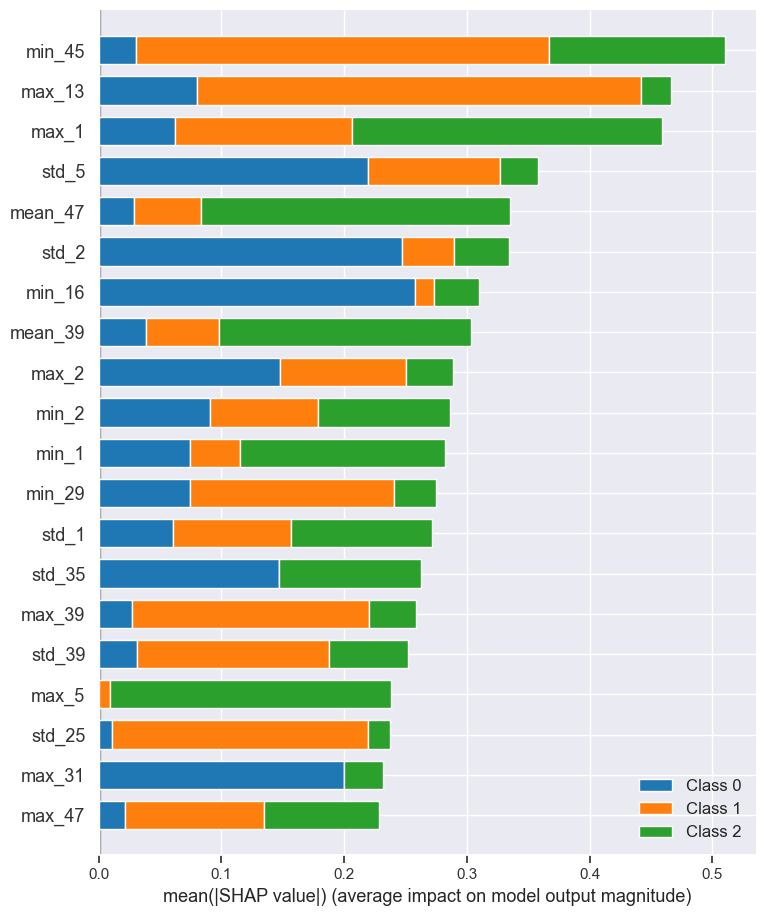

<Figure size 640x480 with 0 Axes>

In [178]:
import shap
import matplotlib.pyplot as pl


explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Xtrain)

shap.summary_plot(shap_values, Xtrain,color=pl.get_cmap("tab10"))
shap_values[1][:2,:]#表示前两个样本对于输出标签为1的shap值
plt.savefig('E:/高密度脑电前额项目/code/EEG/feature_analysis/HD/results/1.jpg')

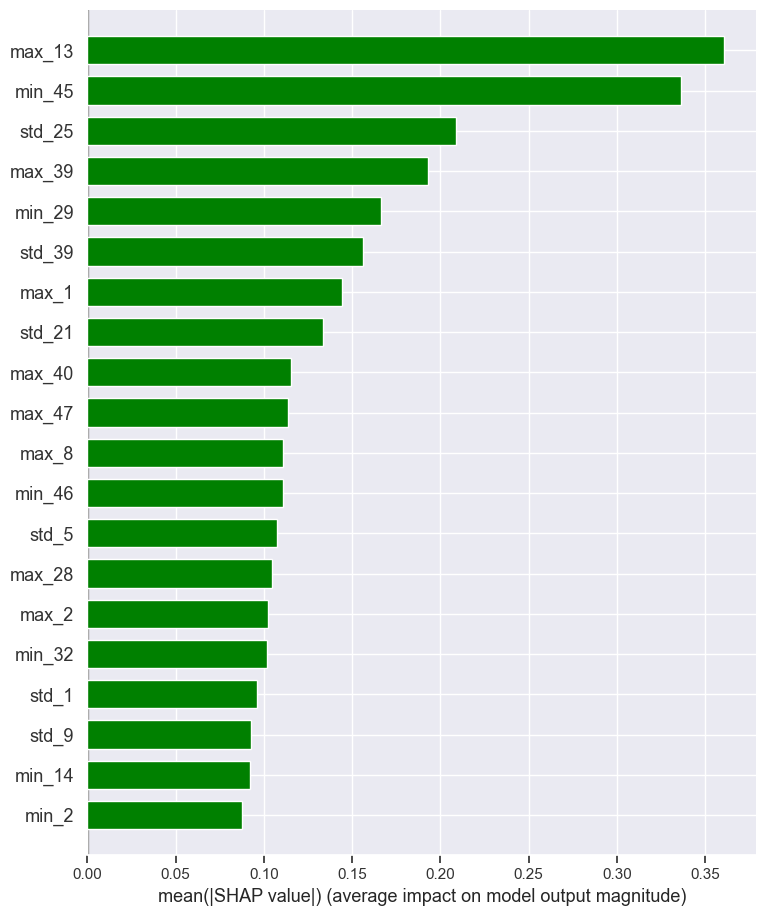

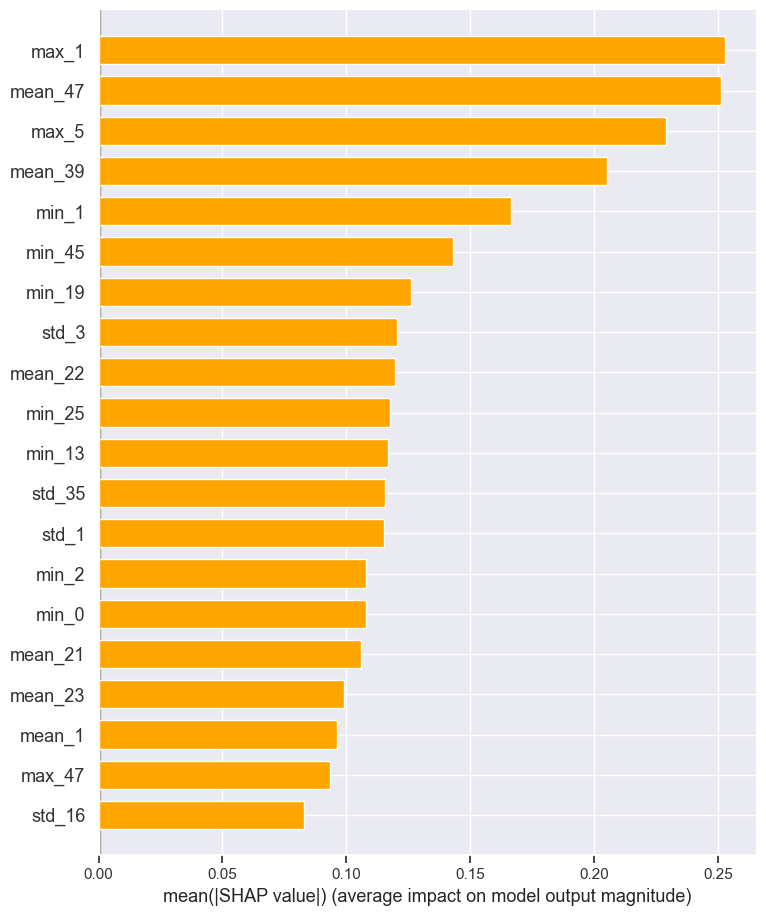

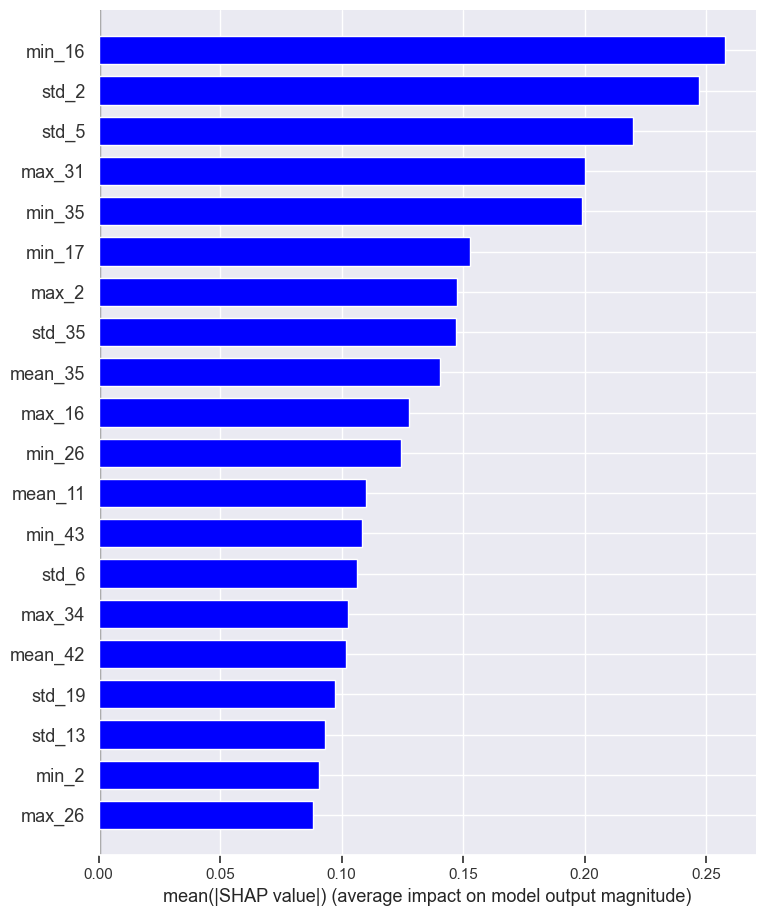

In [174]:
shap.summary_plot(shap_values[1],Xtest, plot_type="bar",color='green')
shap.summary_plot(shap_values[2],Xtest, plot_type="bar",color='orange')
shap.summary_plot(shap_values[0],Xtest, plot_type="bar",color='blue')

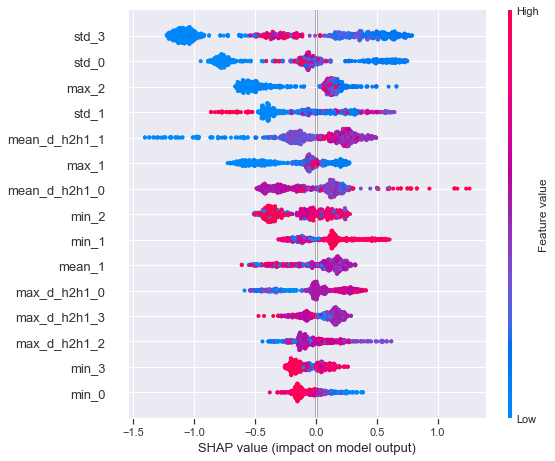

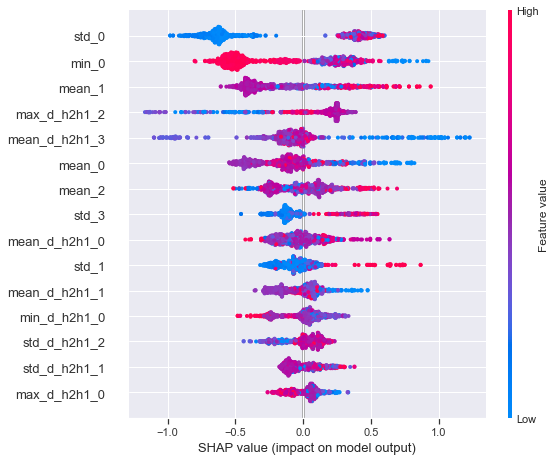

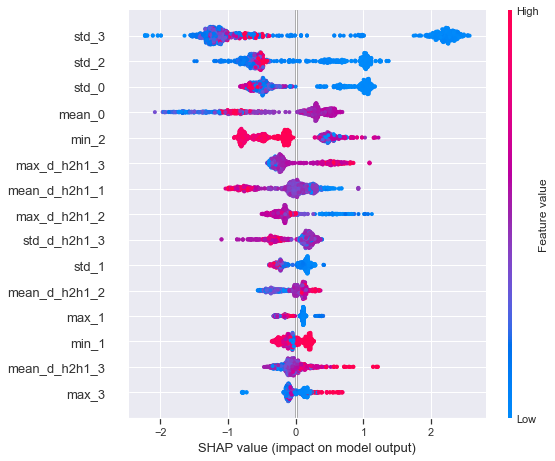

In [29]:
# SHAP值解释
shap.summary_plot(shap_values[1], Xtrain, max_display=15)#消极情感

shap.summary_plot(shap_values[2], Xtrain, max_display=15)#积极情感
shap.summary_plot(shap_values[0], Xtrain, max_display=15)#中性情感

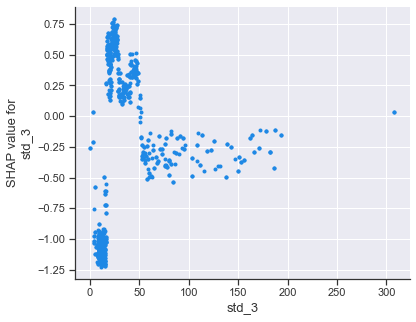

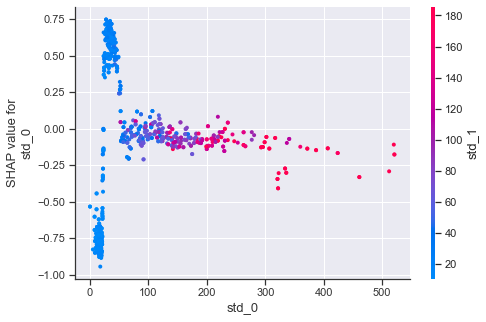

In [30]:
# 单个特征'dangou_ratio'与模型预测结果的关系
shap.dependence_plot('std_3', shap_values[1],Xtrain[x.columns], display_features=Xtrain[x.columns],interaction_index=None)
shap.dependence_plot('std_0', shap_values[1],Xtrain[x.columns], display_features=Xtrain[x.columns],interaction_index='auto')

# ---------------------------分割线-----------------------------

# Embedded嵌入法

In [31]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier as RFC

In [32]:
RFC_ = RFC(n_estimators=10,random_state=0)  # 随机森林实例化

In [33]:
x = data_.iloc[:,:-2]
y = data_.iloc[:,-1]
x.shape

NameError: name 'data_' is not defined

* 阈值为0.005

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.005).fit_transform(x,y)
#在这里我只想取出来有限的特征。0.005这个阈值对于有780个特征的数据来说，是非常高的阈值，因为平均每个特征
# 只能够分到大约0.001的feature_importances_

In [ ]:
x_embedded.shape
#模型的维度明显被降低了
#同样的，我们也可以画学习曲线来找最佳阈值

In [ ]:
RFC_.fit(x,y).feature_importances_

In [ ]:
(RFC_.fit(x,y).feature_importances_).max()

In [ ]:
# 绘制学习曲线
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
RFC_.fit(x,y).feature_importances_
threshold = np.linspace(0,(RFC_.fit(x,y).feature_importances_).max(),20)
#0 - feature_importances_ 范围中取20个数

score = []
for i in threshold:
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y) # 随机森林实例化
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()  # 交叉验证5次
    score.append(once)
plt.plot(threshold,score)
plt.show()

In [ ]:
threshold

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.00870999).fit_transform(x,y)

In [ ]:
x_embedded.shape

In [ ]:
cross_val_score(RFC_,x_embedded,y,cv=5).mean()

In [ ]:
# 确定准确率最高threshold值


score2 = []
for i in np.linspace(0,0.00870999,20):
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y)
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()
    score2.append(once)
plt.figure(figsize=[20,5])
plt.plot(np.linspace(0,0.00870999,20),score2)
plt.xticks(np.linspace(0,0.00870999,20))
plt.show()

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.003209).fit_transform(x,y)

In [ ]:
x_embedded.shape

In [ ]:
cross_val_score(RFC_,x_embedded,y,cv=5).mean()

In [ ]:
cross_val_score(RFC(n_estimators=100,random_state=0),x_embedded,y,cv=5).mean()

* 阈值为0.001

In [ ]:
x_embedded = SelectFromModel(RFC_,threshold=0.001).fit_transform(x,y)
#在这里我只想取出来有限的特征。0.005这个阈值对于有780个特征的数据来说，是非常高的阈值，因为平均每个特征
# 只能够分到大约0.001的feature_importances_

In [ ]:
x_embedded.shape

In [ ]:
RFC_.fit(x,y).feature_importances_

In [ ]:
(RFC_.fit(x,y).feature_importances_).max()

In [ ]:
# 绘制学习曲线
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
RFC_.fit(x,y).feature_importances_
threshold = np.linspace(0,(RFC_.fit(x,y).feature_importances_).max(),20)
#0 - feature_importances_ 范围中取20个数

score = []
for i in threshold:
    x_embedded = SelectFromModel(RFC_,threshold=i).fit_transform(x,y) # 随机森林实例化
    once = cross_val_score(RFC_,x_embedded,y,cv=5).mean()  # 交叉验证5次
    score.append(once)
plt.plot(threshold,score)
plt.show()

In [ ]:
threshold

# Wrapper包装法

In [ ]:
from sklearn.feature_selection import RFE
RFC_ = RFC(n_estimators=10,random_state=0)
selector = RFE(RFC_,n_features_to_select=22,step=5).fit(x,y)  # 每迭代一次删除掉50个特征

In [ ]:
selector.support_.sum() #.support_：返回所有的特征的是否最后被选中的布尔矩阵

In [ ]:
selector.ranking_   #返回特征的按数次迭代中综合重要性的排名,越重要的特征排在前面

In [ ]:
x_wrapper = selector.transform(x)

In [ ]:
cross_val_score(RFC_,x_wrapper,y,cv=5).mean()

In [ ]:
# 绘制学习曲线
score = []
for i in range(1,751,50):
    x_wrapper = RFE(RFC_,n_features_to_select=i, step=50).fit_transform(x,y)
    once = cross_val_score(RFC_,x_wrapper,y,cv=5).mean()
    score.append(once)
plt.figure(figsize=[20,5])
plt.plot(range(1,751,50),score)
plt.xticks(range(1,751,50))
plt.show()